In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética padrão para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 5]

# Carregando a base de dados de risco de crédito
df = pd.read_csv('dados_credito.csv')
print("Base de dados carregada com sucesso!")

Base de dados carregada com sucesso!


In [3]:
print("=== 1. DIMENSÃO DA BASE (Linhas, Colunas) ===")
print(df.shape)

print("\n=== 2. TIPOS DE DADOS POR VARIÁVEL ===")
print(df.dtypes)

print("\n=== 3. SUMÁRIO ESTATÍSTICO DESCRITIVO ===")
# O .T (transposição) deixa a visualização de muitas colunas muito mais limpa no Jupyter
df.describe().T

=== 1. DIMENSÃO DA BASE (Linhas, Colunas) ===
(32581, 12)

=== 2. TIPOS DE DADOS POR VARIÁVEL ===
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

=== 3. SUMÁRIO ESTATÍSTICO DESCRITIVO ===


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


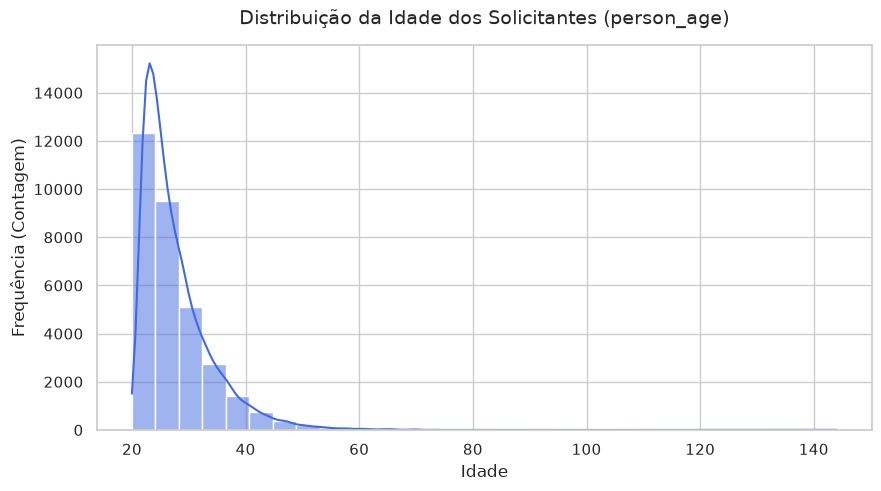

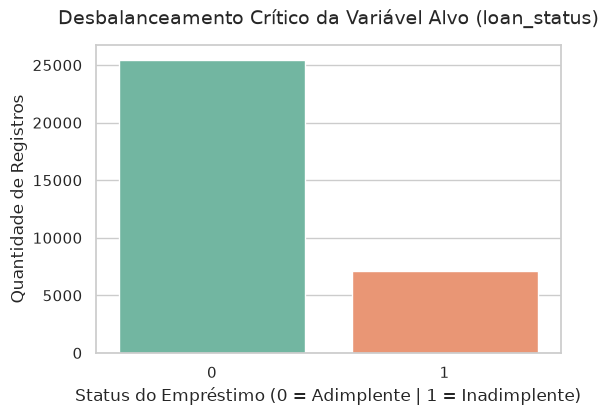

Distribuição exata das classes:
loan_status
0    25473
1     7108
Name: count, dtype: int64


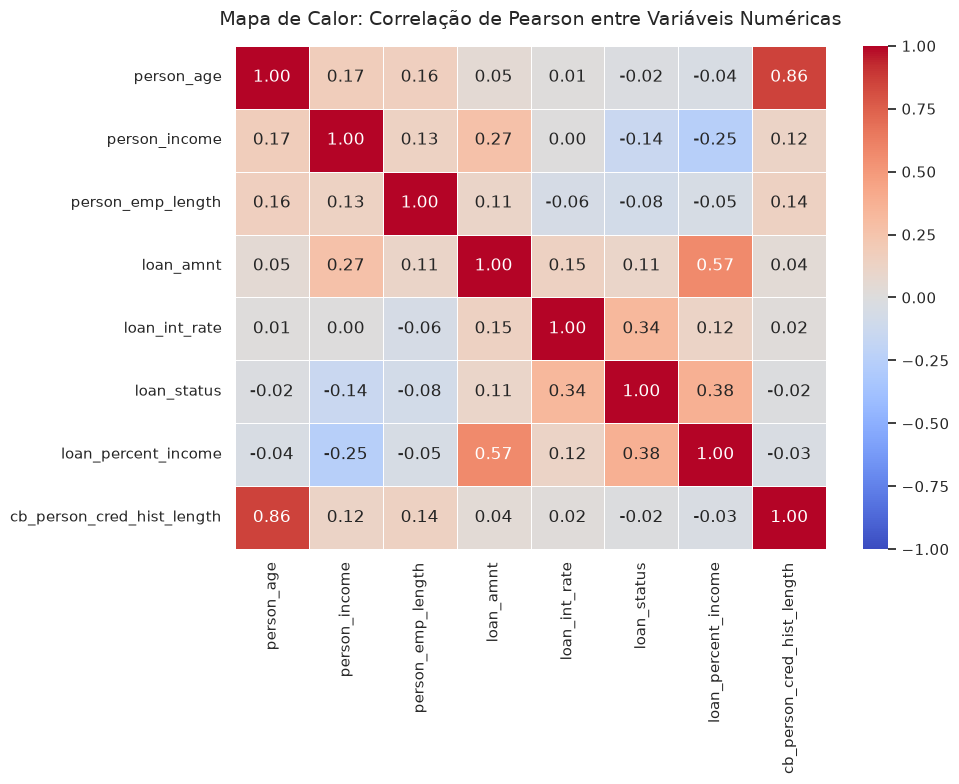

In [4]:
# Gráfico 1: Histograma de Distribuição da Idade dos Solicitantes
plt.figure()
sns.histplot(data=df, x='person_age', bins=30, kde=True, color='royalblue')
plt.title('Distribuição da Idade dos Solicitantes (person_age)', fontsize=14, pad=15)
plt.xlabel('Idade')
plt.ylabel('Frequência (Contagem)')
plt.show()

# Gráfico 2: Gráfico de Barras - Comprovação do Desbalanceamento do Target
plt.figure(figsize=(6, 4))
# Calculando proporções para ajudar no insight posterior
classes_count = df['loan_status'].value_counts()
sns.countplot(data=df, x='loan_status', hue='loan_status', palette='Set2', legend=False)
plt.title('Desbalanceamento Crítico da Variável Alvo (loan_status)', fontsize=14, pad=15)
plt.xlabel('Status do Empréstimo (0 = Adimplente | 1 = Inadimplente)')
plt.ylabel('Quantidade de Registros')
plt.show()

# Exibe as contagens exatas abaixo do gráfico para usarmos no relatório
print("Distribuição exata das classes:")
print(classes_count)

# Gráfico 3: Mapa de Calor - Correlação de Pearson (Apenas variáveis numéricas)
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr(method='pearson')

# Plotando o heatmap com máscaras para facilitar a leitura se necessário
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Calor: Correlação de Pearson entre Variáveis Numéricas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [5]:
# 1. Remoção de Outliers Críticos identificados na EDA (Idade > 100 e Tempo de Emprego > 100)
df_clean = df[df['person_age'] <= 100].copy()
df_clean = df_clean[df_clean['person_emp_length'] <= 100]

# 2. Tratamento Estatístico de Nulos utilizando a Mediana
mediana_emp = df_clean['person_emp_length'].median()
mediana_rate = df_clean['loan_int_rate'].median()

df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(mediana_emp)
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(mediana_rate)

print("=== VALIDAÇÃO APÓS LIMPEZA E IMPUTAÇÃO ===")
print(f"Volume de linhas restante na base limpa: {df_clean.shape[0]}")
print("\nVerificação de valores nulos pendentes:")
print(df_clean.isnull().sum())

=== VALIDAÇÃO APÓS LIMPEZA E IMPUTAÇÃO ===
Volume de linhas restante na base limpa: 31679

Verificação de valores nulos pendentes:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [6]:
# 3. Criação da variável estratégica: Comprometimento Percentual da Renda
df_clean['comprometimento_renda'] = (df_clean['loan_amnt'] / df_clean['person_income']) * 100

print("=== COORDENADAS DA NOVA FEATURE ENGENHARADA ===")
print(df_clean[['loan_amnt', 'person_income', 'comprometimento_renda']].head())

=== COORDENADAS DA NOVA FEATURE ENGENHARADA ===
   loan_amnt  person_income  comprometimento_renda
1       1000           9600              10.416667
2       5500           9600              57.291667
3      35000          65500              53.435115
4      35000          54400              64.338235
5       2500           9900              25.252525


In [7]:
# 1. Isolando a variável alvo (y) e as variáveis preditoras (X)
X = df_clean.drop(columns=['loan_status'])
y = df_clean['loan_status']

# 2. Convertendo variáveis categóricas em numéricas (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Importando o particionador
from sklearn.model_selection import train_test_split

# 4. Divisão paralela em Treino (80%) e Teste (20%) com estratificação para manter a proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("=== ESTRUTURA DOS CONJUNTOS DE DADOS ===")
print(f"Treino (X_train): {X_train.shape} | Teste (X_test): {X_test.shape}")

=== ESTRUTURA DOS CONJUNTOS DE DADOS ===
Treino (X_train): (25343, 23) | Teste (X_test): (6336, 23)


In [8]:
from imblearn.over_sampling import SMOTE

# Aplicando o SMOTE estritamente nos dados de treino para evitar Data Leakage (Vazamento de Dados)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("=== DISTRIBUIÇÃO APÓS APLICAÇÃO DO SMOTE ===")
print(y_train_balanced.value_counts())

=== DISTRIBUIÇÃO APÓS APLICAÇÃO DO SMOTE ===
loan_status
0    19883
1    19883
Name: count, dtype: int64


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Instanciando os algoritmos
# Ajustamos uma profundidade máxima para a árvore não sofrer de overfitting (decorar os dados)
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_arvore = DecisionTreeClassifier(random_state=42, max_depth=8)

# 2. Treinamento com os dados balanceados pelo SMOTE
print("Treinando o modelo KNN... Por favor, aguarde.")
modelo_knn.fit(X_train_balanced, y_train_balanced)

print("Treinando o modelo Árvore de Decisão...")
modelo_arvore.fit(X_train_balanced, y_train_balanced)

# 3. Executando as predições na base de teste (dados reais/não balanceados)
y_pred_knn = modelo_knn.predict(X_test)
y_pred_arvore = modelo_arvore.predict(X_test)

# 4. Exibição dos resultados analíticos
print("\n" + "="*20 + " RELATÓRIO DE MÉTRICAS: KNN " + "="*20)
print(classification_report(y_test, y_pred_knn, target_names=['Adimplente (0)', 'Inadimplente (1)']))

print("\n" + "="*20 + " RELATÓRIO DE MÉTRICAS: ÁRVORE DE DECISÃO " + "="*20)
print(classification_report(y_test, y_pred_arvore, target_names=['Adimplente (0)', 'Inadimplente (1)']))

Treinando o modelo KNN... Por favor, aguarde.
Treinando o modelo Árvore de Decisão...

==================== RELATÓRIO DE MÉTRICAS: KNN ====================
                  precision    recall  f1-score   support

  Adimplente (0)       0.90      0.80      0.85      4971
Inadimplente (1)       0.49      0.68      0.57      1365

        accuracy                           0.78      6336
       macro avg       0.69      0.74      0.71      6336
    weighted avg       0.81      0.78      0.79      6336


==================== RELATÓRIO DE MÉTRICAS: ÁRVORE DE DECISÃO ====================
                  precision    recall  f1-score   support

  Adimplente (0)       0.93      0.96      0.94      4971
Inadimplente (1)       0.83      0.73      0.78      1365

        accuracy                           0.91      6336
       macro avg       0.88      0.84      0.86      6336
    weighted avg       0.91      0.91      0.91      6336

